In [1]:
import json
from db_tools.component_search import search_mpn_part

result = search_mpn_part("SML-D13VWT86C", limit=10)
print(json.dumps(result, indent=2))


{
  "success": true,
  "query": "SML-D13VWT86C",
  "terms": [
    "sml-d13vwt86c"
  ],
  "coreTerms": [],
  "optionalTerms": [
    "sml-d13vwt86c"
  ],
  "limit": 10,
  "offset": 0,
  "count": 1,
  "results": [
    {
      "mpn": "SML-D13VWT86C",
      "package": "0603",
      "footprint": "Optocoupler_LED_Digital_Tube_Photoelectric_Devic:LED0603_RED",
      "library": "Optocoupler_LED_Digital_Tube_Photoelectric_Device",
      "class": "Light Emitting Diodes (LED)",
      "datasheet": "https://datasheet.lcsc.com/lcsc/2302011609_ROHM-Semicon-SML-D13VWT86C_C510030.pdf",
      "joints": 2,
      "score": -10.135993887779284,
      "attributes": {
        "Dominant Wavelength": "630nm",
        "Emitted Color": "Red",
        "Forward Current": "20mA",
        "Forward Voltage (VF)": "2V",
        "Lens Color": "\u767d\u8272\u900f\u955c",
        "Luminous Intensity": "55mcd"
      }
    }
  ]
}


In [2]:
from db_tools.component_search import search_datasheet

result = search_datasheet("SML-D13VWT86C", "Optocoupler_LED_Digital_Tube_Photoelectric_Device")
print(result)


{'success': True, 'mpn': 'SML-D13VWT86C', 'library': 'Optocoupler_LED_Digital_Tube_Photoelectric_Device', 'datasheet': 'https://datasheet.lcsc.com/lcsc/2302011609_ROHM-Semicon-SML-D13VWT86C_C510030.pdf', 'specs': '{"Dominant Wavelength":"630nm","Emitted Color":"Red","Forward Current":"20mA","Forward Voltage (VF)":"2V","Lens Color":"\\u767d\\u8272\\u900f\\u955c","Luminous Intensity":"55mcd"}'}


In [4]:
import json
from db_tools.symbols import get_symbol_pinout

result = get_symbol_pinout(
    library="Optocoupler_LED_Digital_Tube_Photoelectric_Device",
    mpn="SML-D13VWT86C",
)

print(json.dumps(result, indent=2))


{
  "success": true,
  "message": "Retrieved pinout for Optocoupler_LED_Digital_Tube_Photoelectric_Device:SML-D13VWT86C",
  "symbol": "SML-D13VWT86C",
  "library": "Optocoupler_LED_Digital_Tube_Photoelectric_Device",
  "pinCount": 2,
  "pins": [
    {
      "number": "1",
      "name": "A",
      "type": "unspecified"
    },
    {
      "number": "2",
      "name": "K",
      "type": "unspecified"
    }
  ]
}


43
TPS62087RLTR Power_Supply_Chip


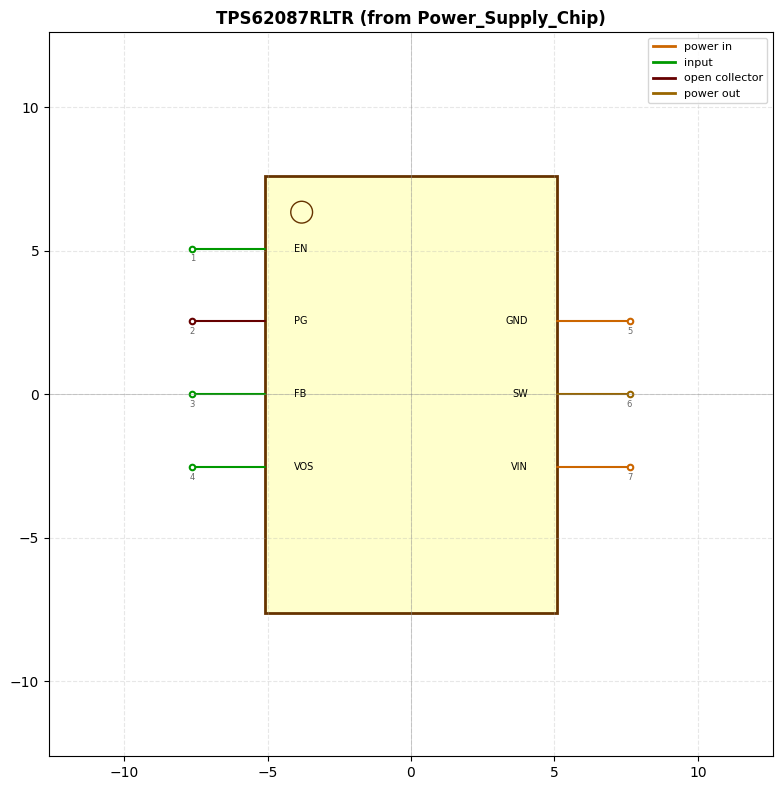

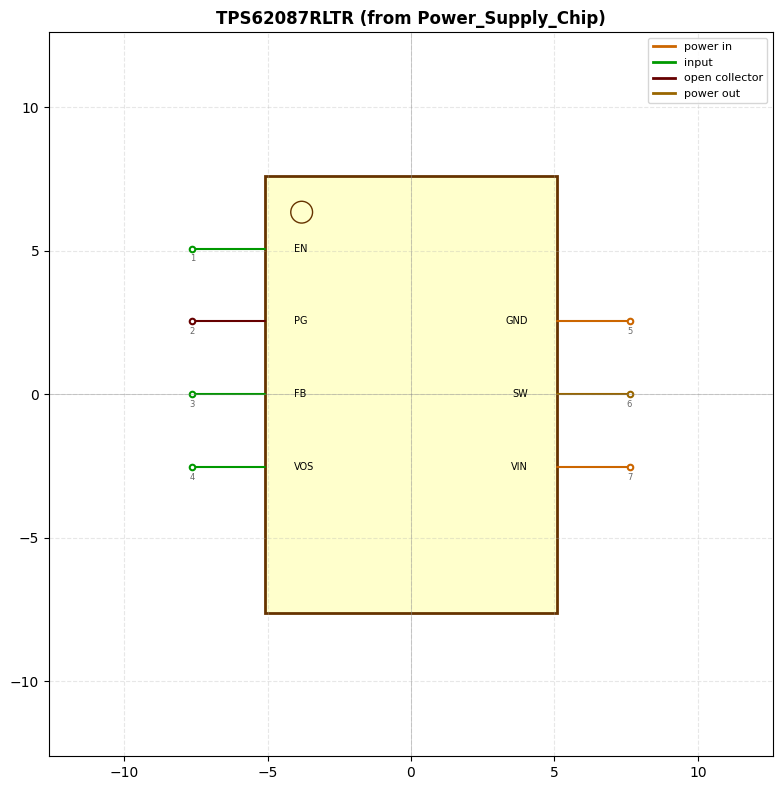

In [5]:
from pathlib import Path
from db_tools.sqlite import connect_sqlite
from python.commands.database_tools.symbol_visualizer import visualize_by_mpn

tracker_db = Path("datasheets") / "datasheet_tracker"

with connect_sqlite(tracker_db, readonly=True) as conn:
    entries = [dict(row) for row in conn.execute("SELECT * FROM datasheet_tracker").fetchall()]

print(len(entries))

idx = 8
name = entries[idx]["symbol_name"]
lib = entries[idx]["library"]
print(name, lib)

visualize_by_mpn(name, lib, show=False)


In [ ]:
from python.netlist_schematic_pipeline import generate_schematic_from_skidl_module

res = generate_schematic_from_skidl_module(
    skidl_module_path="test_cases/int_3ACharger_noSim/skidl/modules/usb_in.py",
    subcircuit_name="USB_IN",
    output_path="exported/test/usb_in.kicad_sch",
    # logic_hints_path="test_cases/int_3ACharger_noSim/organizer/usb_in_logic.json",
    export_svg=True,
    verify=True,
    optimize_rotation=True,
)

In [ ]:
from python.netlist_schematic_pipeline import generate_schematic_from_skidl_module

skidl_module_path="test_cases/NoSim_HiFi/skidl/modules/dual_rail_gen.py"

subcircuit_name = skidl_module_path.split("/")[-1].split(".")[0].upper()
output_path = f"exported/test/{subcircuit_name.lower()}.kicad_sch"


res = generate_schematic_from_skidl_module(
    skidl_module_path=skidl_module_path,
    subcircuit_name=subcircuit_name,
    output_path=output_path,
    export_svg=True,
    verify=True,
    keep_intermediate=False,
    optimize_rotation=True,
    use_direct_connections=True,
    label_high_fanout_nets=False,
    cluster_components=True,
    cluster_max_connections=5,
    cluster_min_size=4,
    cluster_max_size=0,
    cluster_ignore_fanout_ge=8,
)

res